# Differentiating a full PM++ simulation

{bdg-danger}`2 CUDA GPUs required` {bdg-secondary}`256^3 float64 adjoint` {bdg-success}`pre-executed`

This notebook differentiates a scalar density loss through linear modes, 2LPT, the full
N-body solve, particle migration, and CIC scatter.  It then exercises the hand-written
N-body cosmology adjoint for `Omega_m` while holding the already tabulated transfer and
growth arrays fixed.  Both derivatives are checked against central finite differences.

The entire forward and gradient callable is JIT-compiled as one unit.  That is the
validated usage pattern for the static sharding contracts in the custom adjoint.

```{admonition} Committed execution record
:class: note
All outputs and plots on this page are committed in the notebook; hosted documentation
does not execute them.  The first executed output is the environment and configuration
record for the published run.
```


In [1]:
%matplotlib inline
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pmpp.boltzmann import boltzmann
from pmpp.configuration import Configuration
from pmpp.cosmo import SimpleLCDM
from pmpp.lpt import lpt
from pmpp.modes import linear_modes, white_noise
from pmpp.multigpu_configuration import MultiGPUConfiguration
from pmpp.nbody import nbody
from pmpp.scatter import scatter
from pmpp.utils import create_compute_mesh

gpu_devices = [device for device in jax.devices() if device.platform == "gpu"][:2]
if len(gpu_devices) != 2:
    raise RuntimeError("This precomputed adjoint notebook requires two visible CUDA devices.")

SEED = 1
RESOLUTION = 256
execution_record = {
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "selected_device_count": len(gpu_devices),
    "visible_device_count": len(jax.devices()),
    "selected_device_models": [device.device_kind for device in gpu_devices],
    "seed": SEED,
    "configuration": {
        "box_size_mpc_h": 100.0,
        "particle_grid": (RESOLUTION,) * 3,
        "mesh_ratio": 1,
        "lpt_order": 2,
        "a_start": 1 / 64,
        "a_stop": 1.0,
        "a_nbody_maxstep": 1 / 64,
        "mode": "mesh_halo",
        "dtype": "float64",
    },
    "capacities": {
        "max_ptcl_per_slice": 10_066_329,
        "max_share_ptcl": 1_600_000,
        "max_halo_share_ptcl": 800_000,
        "max_share_gather_ptcl": 1_800_000,
    },
}
print("PM++ DOCUMENTATION EXECUTION RECORD")
for key, value in execution_record.items():
    print(f"{key}: {value}")
compute_mesh = create_compute_mesh(gpu_devices)
conf = Configuration(
    ptcl_spacing=100.0 / RESOLUTION,
    ptcl_grid_shape=(RESOLUTION,) * 3,
    mesh_shape=1,
    multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
    max_ptcl_per_slice=10_066_329,
    max_share_ptcl=1_600_000,
    max_halo_share_ptcl=800_000,
    max_share_gather_ptcl=1_800_000,
    a_start=1 / 64,
    a_stop=1.0,
    a_nbody_maxstep=1 / 64,
    cosmo_dtype=jnp.float64,
    float_dtype=jnp.float64,
)
base_cosmo = SimpleLCDM(conf)
print("devices:", [device.device_kind for device in gpu_devices])
print("N-body schedule:", np.asarray(conf.a_nbody))
print("effective capacities:", {
    "max_ptcl_per_slice": conf.max_ptcl_per_slice,
    "max_share_ptcl": conf.max_share_ptcl,
    "max_halo_share_ptcl": conf.max_halo_share_ptcl,
    "max_share_gather_ptcl": conf.max_share_gather_ptcl,
})


PM++ DOCUMENTATION EXECUTION RECORD
jax_version: 0.6.2
backend: gpu
selected_device_count: 2
visible_device_count: 2
selected_device_models: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
seed: 1
configuration: {'box_size_mpc_h': 100.0, 'particle_grid': (256, 256, 256), 'mesh_ratio': 1, 'lpt_order': 2, 'a_start': 0.015625, 'a_stop': 1.0, 'a_nbody_maxstep': 0.015625, 'mode': 'mesh_halo', 'dtype': 'float64'}
capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000}


devices: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']


N-body schedule: [0.015625 0.03125  0.046875 0.0625   0.078125 0.09375  0.109375 0.125
 0.140625 0.15625  0.171875 0.1875   0.203125 0.21875  0.234375 0.25
 0.265625 0.28125  0.296875 0.3125   0.328125 0.34375  0.359375 0.375
 0.390625 0.40625  0.421875 0.4375   0.453125 0.46875  0.484375 0.5
 0.515625 0.53125  0.546875 0.5625   0.578125 0.59375  0.609375 0.625
 0.640625 0.65625  0.671875 0.6875   0.703125 0.71875  0.734375 0.75
 0.765625 0.78125  0.796875 0.8125   0.828125 0.84375  0.859375 0.875
 0.890625 0.90625  0.921875 0.9375   0.953125 0.96875  0.984375 1.      ]
effective capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000}


## Full initial-mode gradient

The scalar loss is the variance of the final density field. `modes_real` is a full
real-space white-noise array, so the returned gradient has one sensitivity per initial
cell without embedding another $256^3$ target field as a compile-time constant.


In [2]:
def forward_density(modes_real, cosmology):
    evolved_cosmo = boltzmann(cosmology, conf)
    modes = linear_modes(modes_real, evolved_cosmo, conf)
    particles = lpt(modes, evolved_cosmo, conf)
    particles = nbody(particles, evolved_cosmo, conf)
    return scatter(particles, conf)

compiled_forward = jax.jit(forward_density)
make_real_noise = jax.jit(lambda seed: white_noise(seed, conf, real=True))

def density_loss(modes_real):
    return jnp.var(forward_density(modes_real, base_cosmo))

value_and_mode_grad = jax.jit(jax.value_and_grad(density_loss))
compiled_density_loss = jax.jit(density_loss)
input_modes = make_real_noise(SEED)
input_density = compiled_forward(input_modes, base_cosmo)
input_density.block_until_ready()
loss_value, mode_gradient = value_and_mode_grad(input_modes)
mode_gradient.block_until_ready()

print(f"loss={float(loss_value):.12e}")
print(f"initial-mode gradient norm={float(jnp.linalg.norm(mode_gradient)):.12e}")


loss=1.260681871603e+02
initial-mode gradient norm=1.392880048152e+02


In [3]:
direction = jax.random.normal(jax.random.PRNGKey(4), input_modes.shape, dtype=input_modes.dtype)
direction = direction / jnp.linalg.norm(direction)
epsilon_modes = jnp.asarray(5e-2, dtype=input_modes.dtype)

analytic_directional = jnp.vdot(mode_gradient, direction)
finite_difference_directional = (
    compiled_density_loss(input_modes + epsilon_modes * direction)
    - compiled_density_loss(input_modes - epsilon_modes * direction)
) / (2 * epsilon_modes)
mode_relative_error = jnp.abs(analytic_directional - finite_difference_directional) / jnp.maximum(
    jnp.abs(finite_difference_directional), 1e-12
)

assert float(mode_relative_error) < 5e-2
print(f"mode directional AD={float(analytic_directional):.12e}")
print(f"mode directional FD={float(finite_difference_directional):.12e}")
print(f"relative error={float(mode_relative_error):.3e}")


mode directional AD=-9.840481011568e-03
mode directional FD=-9.863283473805e-03
relative error=2.312e-03


## Selected cosmology sensitivity in the N-body adjoint

For this check, initial particles and the tabulated transfer/growth arrays are fixed.  We
vary `Omega_m` only in the N-body dynamics.  This isolates the custom N-body cosmology
cotangent; it is not the total derivative that would also differentiate the Boltzmann
table construction.


In [4]:
evolved_cosmo = boltzmann(base_cosmo, conf)
initialize_particles = jax.jit(
    lambda seed: lpt(
        linear_modes(white_noise(seed, conf), evolved_cosmo, conf),
        evolved_cosmo,
        conf,
    )
)
initial_particles = initialize_particles(SEED)

def omega_m_loss(omega_m):
    varied_cosmo = evolved_cosmo.replace(Omega_m=omega_m)
    density = scatter(nbody(initial_particles, varied_cosmo, conf), conf)
    return jnp.var(density)

omega_value_and_grad = jax.jit(jax.value_and_grad(omega_m_loss))
compiled_omega_m_loss = jax.jit(omega_m_loss)
omega_loss_value, omega_gradient = omega_value_and_grad(evolved_cosmo.Omega_m)

epsilon_omega = jnp.asarray(1e-5, dtype=evolved_cosmo.Omega_m.dtype)
omega_finite_difference = (
    compiled_omega_m_loss(evolved_cosmo.Omega_m + epsilon_omega)
    - compiled_omega_m_loss(evolved_cosmo.Omega_m - epsilon_omega)
) / (2 * epsilon_omega)
omega_relative_error = jnp.abs(omega_gradient - omega_finite_difference) / jnp.maximum(
    jnp.abs(omega_finite_difference), 1e-12
)

print(f"Omega_m loss={float(omega_loss_value):.12e}")
print(f"d loss / d Omega_m (adjoint)={float(omega_gradient):.12e}")
print(f"d loss / d Omega_m (finite difference)={float(omega_finite_difference):.12e}")
print(f"relative error={float(omega_relative_error):.3e}")
assert np.isfinite(float(omega_gradient))
assert float(omega_relative_error) < 1e-2


Omega_m loss=1.260681873594e+02
d loss / d Omega_m (adjoint)=2.606669358538e+01
d loss / d Omega_m (finite difference)=2.622883833965e+01
relative error=6.182e-03


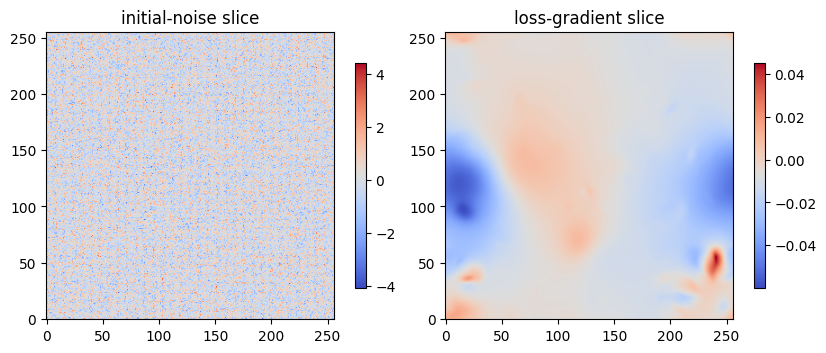

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.4), constrained_layout=True)
image0 = axes[0].imshow(np.asarray(input_modes)[0], origin="lower", cmap="coolwarm")
axes[0].set_title("initial-noise slice")
fig.colorbar(image0, ax=axes[0], shrink=0.78)
image1 = axes[1].imshow(np.asarray(mode_gradient)[0], origin="lower", cmap="coolwarm")
axes[1].set_title("loss-gradient slice")
fig.colorbar(image1, ax=axes[1], shrink=0.78)
plt.show()


This 256-cube validation uses the production resolution and schedule. A gradient includes
both the forward solve and the custom reverse sweep and is substantially more expensive
than a forward run; keep the loss, sharding, capacities, and gradient target fixed when
comparing timings or numerical checks.
